# WarpKriging with ordinal warping (R)

The **ordinal** warp maps each level $\ell \in \{0, \ldots, L-1\}$ to a learned position
on $\mathbb{R}$, respecting the natural ordering. This is appropriate when one input is
discrete and ordered (e.g., resolution level, quality grade).

Here we discretize $x_1$ of the Branin function into 5 ordered levels while keeping $x_2$ continuous.

Steps:
1. Install rlibkriging (run once)
2. Load rlibkriging
3. Define the Branin function and plot it
4. Build a space-filling design and evaluate it
5. Fit a `WarpKriging` model
6. Predict on a fine grid and plot mean + uncertainty
7. Inspect model parameters

## 0. Installation (run once)

Build the C++ core and the R binding from source.
Requires: `cmake`, a C++ compiler, and R development headers.

The script `tools/r-linux-macos/build.sh` calls `tools/linux-macos/build.sh`
to build the C++ core, then runs `make` in `bindings/R` to compile and install
**rlibkriging** into `bindings/R/Rlibs`.

In [1]:
# Run this cell once to build and install rlibkriging.
# Skip if already built (bindings/R/Rlibs/rlibkriging exists).
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
rlibs     <- file.path(repo_root, "bindings", "R", "Rlibs", "rlibkriging")

if (!dir.exists(rlibs)) {
  message("Building rlibkriging from source…")
  ret <- system(paste0("cd '", repo_root, "' && bash tools/r-linux-macos/build.sh"))
  if (ret != 0) stop("Build failed — check compiler and cmake installation.")
} else {
  message("rlibkriging already built, skipping.")
}

rlibkriging already built, skipping.



## 1. Load rlibkriging

In [2]:
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
lib_path  <- file.path(repo_root, "bindings", "R", "Rlibs")
library(rlibkriging, lib.loc = lib_path)


Attachement du package : ‘rlibkriging’




L'objet suivant est masqué depuis ‘package:stats’:

    kernel




Les objets suivants sont masqués depuis ‘package:base’:

    beta, load, save




## 2. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).
It has three global minima.

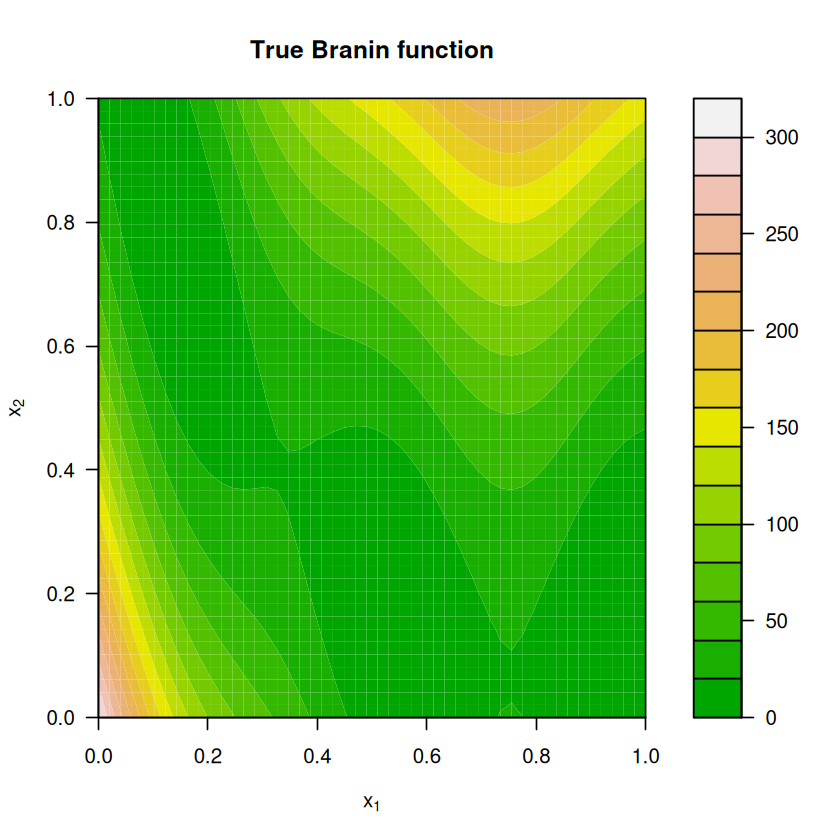

In [3]:
branin <- function(x) {
  if (!is.matrix(x)) x <- matrix(x, nrow = 1)
  x1 <- x[, 1] * 15 - 5
  x2 <- x[, 2] * 15
  (x2 - 5 / (4 * pi^2) * x1^2 + 5 / pi * x1 - 6)^2 +
    10 * (1 - 1 / (8 * pi)) * cos(x1) + 10
}

# Visualise true function on a 50x50 grid
grid_x <- seq(0, 1, length.out = 50)
grid   <- as.matrix(expand.grid(x1 = grid_x, x2 = grid_x))
z_true <- matrix(branin(grid), 50, 50)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = "True Branin function",
  xlab = expression(x[1]), ylab = expression(x[2])
)

## 3. Design of experiments

We discretize $x_1$ into 5 ordinal levels (0, 1, ..., 4), each mapped to an
equally spaced center in $[0, 1]$, and sample $n = 40$ points.

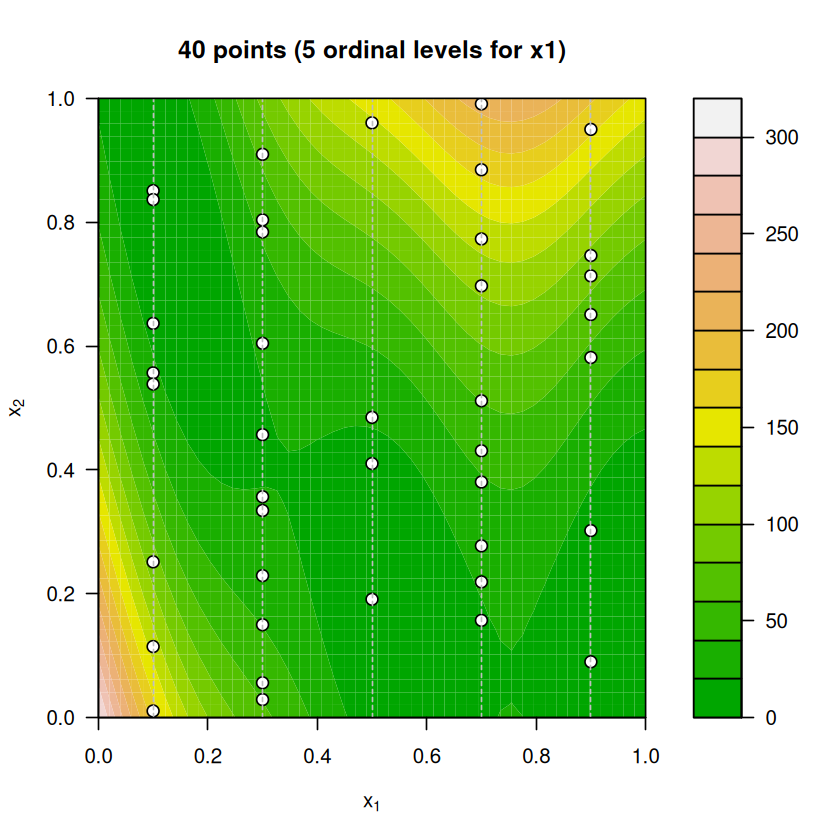

In [4]:
set.seed(42)
L <- 5  # number of ordinal levels
n <- 40
centers <- seq(0.1, 0.9, length.out = L)

lhs <- function(n, d) {
  X <- matrix(NA, n, d)
  for (j in seq_len(d))
    X[, j] <- (sample(n) - runif(n)) / n
  X
}

# x1 is ordinal: randomly assign levels
x1_level <- sample(0:(L - 1), n, replace = TRUE)
x2 <- lhs(n, 1)[, 1]

# Evaluate Branin at the level's center for x1
X_eval <- cbind(centers[x1_level + 1], x2)
y <- branin(X_eval)

# For WarpKriging, x1 is passed as integer level (0..L-1)
X <- cbind(as.numeric(x1_level), x2)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = paste0(n, " points (", L, " ordinal levels for x1)"),
  xlab = expression(x[1]), ylab = expression(x[2]),
  plot.axes = {
    axis(1); axis(2)
    points(X_eval[, 1], X_eval[, 2], pch = 21, bg = "white", cex = 1.2)
    for (lvl in seq_len(L))
      abline(v = centers[lvl], col = "grey", lty = 2)
  }
)

## 4. Fit a WarpKriging model (`ordinal`)

We use `ordinal(5)` for $x_1$ (5 ordered levels → learned positions on $\mathbb{R}$)
and `kumaraswamy` for the continuous $x_2$.

In [5]:
wk <- WarpKriging(
  y, X,
  warping = c('ordinal(5)', 'kumaraswamy'),
  kernel = "matern5_2",
  optim = "Adam",
  parameters = list(max_iter_adam = '500')
)
print(wk)

* WarpKriging
* data: 40x[0,4],[0.0106631,0.991108] -> 40x[1.13612,206.94]
* trend constant (est.): 2252.13
* variance (est.): 2.56823e+06
* covariance:
  * kernel: matern5_2
  * range (est.): 6.40859, 7.6255
  * warpings:
      x0: "ordinal(5)"  →  Ordinal(L=5, positions=        0   1.0000   2.0000   3.0000   4.0000
)
      x1: "kumaraswamy"  →  Kumaraswamy(a=1, b=1)
  * total warp params: 6
  * fit:
    * objective: LL
    * optim: Adam


## 5. Predict and plot

We predict at each level over a dense grid for $x_2$.

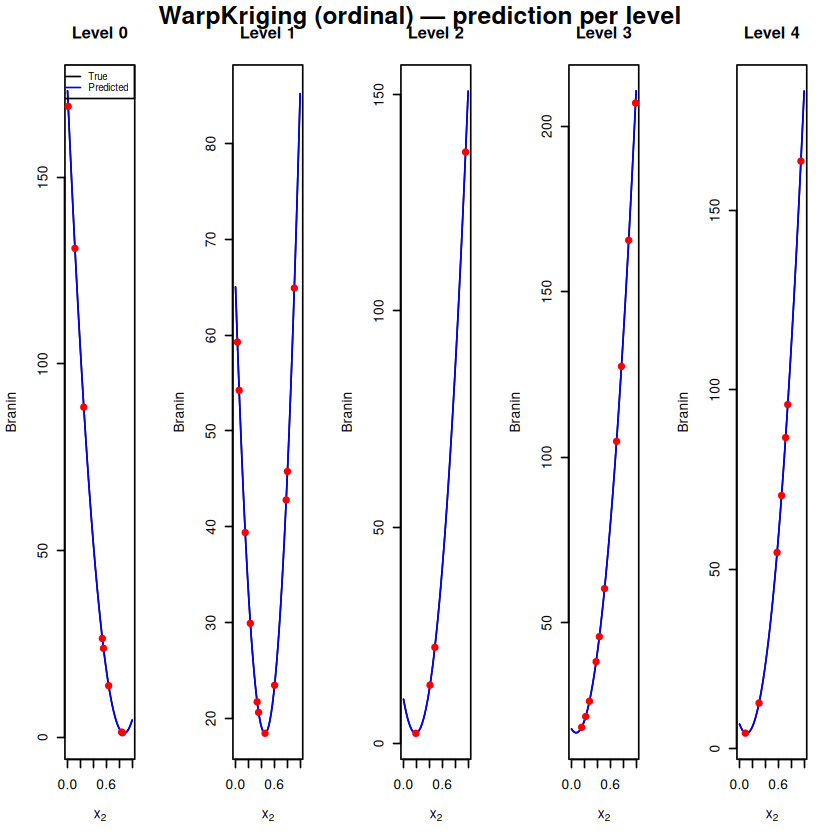

In [6]:
x2_grid <- seq(0, 1, length.out = 50)

par(mfrow = c(1, L))
for (lvl in 0:(L - 1)) {
  X_pred <- cbind(rep(lvl, 50), x2_grid)
  p <- predict(wk, X_pred, return_stdev = TRUE)
  mu <- as.numeric(p$mean)
  sd <- as.numeric(p$stdev)

  # True Branin at this level's center
  X_true <- cbind(rep(centers[lvl + 1], 50), x2_grid)
  y_true <- branin(X_true)

  ylims <- range(c(y_true, mu - 2*sd, mu + 2*sd))
  plot(x2_grid, y_true, type = "l", col = "black", ylim = ylims,
       main = paste("Level", lvl), xlab = expression(x[2]), ylab = "Branin")
  lines(x2_grid, mu, col = "blue")
  polygon(c(x2_grid, rev(x2_grid)),
          c(mu - 2*sd, rev(mu + 2*sd)),
          col = rgb(0, 0, 1, 0.2), border = NA)

  mask <- x1_level == lvl
  points(x2[mask], y[mask], col = "red", pch = 19, cex = 0.8)

  if (lvl == 0) legend("topright", legend = c("True", "Predicted"),
                        col = c("black", "blue"), lty = 1, cex = 0.7)
}
par(mfrow = c(1, 1))
title(paste0("WarpKriging (ordinal) — prediction per level"), outer = TRUE, line = -1)

## 6. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, log-likelihood, and warping specification.

In [7]:
cat("Kernel       :", kernel(wk), "\n")
cat("Theta (range):", round(theta(wk), 4), "\n")
cat("Sigma2       :", round(sigma2(wk), 4), "\n")
cat("LogLikelihood:", round(logLikelihood(wk), 4), "\n")
cat("Warping      :", warping(wk), "\n")

Kernel       : matern5_2 


Theta (range): 6.4086 7.6255 


Sigma2       : 2568234 


LogLikelihood: -40.6178 


Warping      : ordinal(5) kumaraswamy 
